# Handwritten Digit Recognition Using Artificial Neural Networks

In [25]:
# Import NumPy for numerical operations and array handling
import numpy as np

# Import Matplotlib for plotting and visualizing images
import matplotlib.pyplot as plt

# Import MNIST dataset from Keras
# This dataset contains handwritten digit images (0–9)
from tensorflow.keras.datasets import mnist

In [26]:
# Load the MNIST dataset
# x_train -> training images
# y_train -> training labels
# x_test  -> testing images
# y_test  -> testing labels
(x_train, y_train), (x_test, y_test) = mnist.load_data()

* The MNIST dataset is divided into 60,000 training images and 10,000 testing images, each of size 28×28 pixels with corresponding digit labels.

In [27]:
# Print the shape of training images
# Format: (number_of_samples, image_height, image_width)
print("Shape of training set:", x_train.shape)

# Print the shape of training labels
# One label for each training image
print("Shape of training labels:", y_train.shape)

# Print the shape of test images
print("Shape of test set:", x_test.shape)

# Print the shape of test labels
# One label for each test image
print("Shape of test labels:", y_test.shape)


Shape of training set: (60000, 28, 28)
Shape of training labels: (60000,)
Shape of test set: (10000, 28, 28)
Shape of test labels: (10000,)


**Observations**

* The dataset contains 60,000 training images and 10,000 testing images.

* Each image is a 28×28 grayscale image.

* Labels are digits from 0 to 9, making it a multi-class classification problem.

* The dataset is well-balanced and suitable for training neural networks.

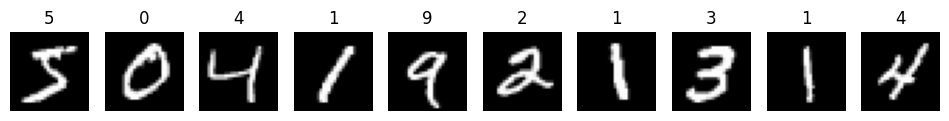

In [28]:
# Create a figure with a wide size to display multiple images
plt.figure(figsize=(12, 3))

# Loop through the first 10 training images
for i in range(10):

    # Create a subplot: 1 row, 10 columns, position i+1
    plt.subplot(1, 10, i + 1)

    # Display the image in grayscale
    plt.imshow(x_train[i], cmap='gray')

    # Set the title as the corresponding digit label
    plt.title(y_train[i])

    # Remove axis ticks for better visualization
    plt.axis('off')

# Show the plotted images
plt.show()


**Observations**

* The images are 28×28 grayscale pixels.

* Handwritten digits from 0 to 9 are clearly visible.

* Different writing styles are observed for the same digit.

* Visualizing data helps in understanding the dataset before training

In [29]:
# Import Sequential model to build a linear stack of layers
from tensorflow.keras.models import Sequential

# Import Dense for fully connected layers
# Import Flatten to convert 2D images into 1D vectors
from tensorflow.keras.layers import Dense, Flatten

# Import to_categorical to convert labels into one-hot encoded format
from tensorflow.keras.utils import to_categorical

# Import evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

# Import Seaborn for better visualization of confusion matrix
import seaborn as sns


In [30]:
# Convert training images to float32 and normalize pixel values
# Original pixel values range from 0 to 255
# After division by 255.0, values will be in the range 0 to 1
x_train_scaled = x_train.astype('float32') / 255.0

# Convert testing images to float32 and normalize pixel values
x_test_scaled = x_test.astype('float32') / 255.0


**Observations**

* Pixel values are successfully normalized to the range [0, 1].

* Normalized images help the ANN learn efficiently.

* Training becomes more stable and faster.

In [31]:
x_train_scaled

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

 * The training images are normalized to the range [0, 1] to improve neural network performance.

In [32]:
x_train_scaled[:1]
#This line selects the first training image from the normalized MNIST dataset.

array([[[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.

In [33]:
x_test_scaled[:1]

array([[[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.

The first test image is extracted with normalized pixel values in the range [0, 1] while maintaining the batch dimension.

In [34]:
# Convert training labels (0–9) into one-hot encoded format
# 10 represents the total number of digit classes
y_train_encoded = to_categorical(y_train, 10)

# Convert testing labels (0–9) into one-hot encoded format
y_test_encoded = to_categorical(y_test, 10)

In [35]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

* y_train contains the true digit labels corresponding to the training images in the MNIST dataset.

In [36]:
y_train_encoded[:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

* The first 10 training labels are converted into one-hot encoded vectors, each representing one digit class.

In [37]:
# Loop through the first 10 samples in the training dataset
for i in range(10):

    # Print the original class label and its One-Hot Encoded (OHE) version
    # y_train[i]           → original label (e.g., 0, 1, 2, etc.)
    # y_train_encoded[i]   → one-hot encoded form of that label
    print(
        "Original Label:", y_train[i],
        "→ OHE:", y_train_encoded[i]
    )

Original Label: 5 → OHE: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Original Label: 0 → OHE: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Original Label: 4 → OHE: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
Original Label: 1 → OHE: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
Original Label: 9 → OHE: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
Original Label: 2 → OHE: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
Original Label: 1 → OHE: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
Original Label: 3 → OHE: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
Original Label: 1 → OHE: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
Original Label: 4 → OHE: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


* The original digit labels are correctly converted into one-hot encoded vectors, where the index corresponding to the digit is set to 1.

In [38]:
# Create a Sequential ANN model
# Layers are added one after another
model = Sequential([

    # Flatten layer
    # Converts 28x28 image into a 1D vector of size 784
    Flatten(input_shape=(28, 28)),

    # First hidden layer
    # 128 neurons with ReLU activation
    Dense(128, activation='relu'),

    # Second hidden layer
    # 64 neurons with ReLU activation
    Dense(64, activation='relu'),

    # Output layer
    # 10 neurons for digits 0-9
    # Softmax converts outputs into probability values
    Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


* A multi-layer ANN with ReLU hidden layers and a softmax output layer is constructed for handwritten digit classification.

In [39]:
# Compile the ANN model
# optimizer='adam' -> updates weights efficiently during training
# loss='categorical_crossentropy' -> used for multi-class classification with one-hot labels
# metrics=['accuracy'] -> measures how many predictions are correct
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
# Train (fit) the ANN model on the training data
history = model.fit(

    x_train_scaled,      # Normalized training images
    y_train_encoded,     # One-hot encoded training labels

    epochs=10,           # Number of times the model sees the full dataset
    batch_size=32,       # Number of samples processed before weight update

    validation_split=0.2 # 20% of training data used for validation
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8579 - loss: 0.4801 - val_accuracy: 0.9566 - val_loss: 0.1409
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9660 - loss: 0.1101 - val_accuracy: 0.9662 - val_loss: 0.1128
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9758 - loss: 0.0744 - val_accuracy: 0.9701 - val_loss: 0.0976
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9828 - loss: 0.0552 - val_accuracy: 0.9745 - val_loss: 0.0863
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9862 - loss: 0.0419 - val_accuracy: 0.9726 - val_loss: 0.0945
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9890 - loss: 0.0327 - val_accuracy: 0.9752 - val_loss: 0.0999
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9912 - loss: 0.0268 - val_accuracy: 0.9721 - val_loss: 0.1033
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9922 - loss: 0.0226 - 

**Observations**

* The ANN model successfully trained for 10 epochs.

* Training and validation accuracy improved over epochs.

* Validation data helped monitor model performance.

* The model learned to recognize handwritten digits effectively

In [41]:
# Evaluate the trained model using test data
# Returns loss value and accuracy score
test_loss, test_acc = model.evaluate(
    x_test_scaled,     # Normalized test images
    y_test_encoded     # One-hot encoded test labels
)

# Print test accuracy and loss in a formatted way
print(f"\nTest Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9753 - loss: 0.1005

Test Accuracy: 0.9776, Test Loss: 0.0919


**Observations**

* The ANN model achieves high accuracy on the test dataset.

* The test loss is low, indicating effective learning.

* The model generalizes well to unseen handwritten digit images

In [42]:
# Predict probability values for each digit class (0–9)
y_pred_probs = model.predict(x_test_scaled)

# Convert predicted probabilities into class labels
# argmax selects the index of the highest probability
y_pred = np.argmax(y_pred_probs, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [43]:
# Generate a detailed classification report
# y_test -> true digit labels
# y_pred -> predicted digit labels
cr = classification_report(y_test, y_pred)

# Print heading
print("\nClassification Report:")

# Print the report
print(cr)



Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.96      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.97      0.98      0.98       982
           5       0.97      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.96      0.97       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



**Observations**

* The model achieves high precision and recall for most digits.

* F1-scores are balanced, indicating good classification.

* Overall accuracy is high, showing effective digit recognition.

* The ANN performs well on unseen handwritten digits.

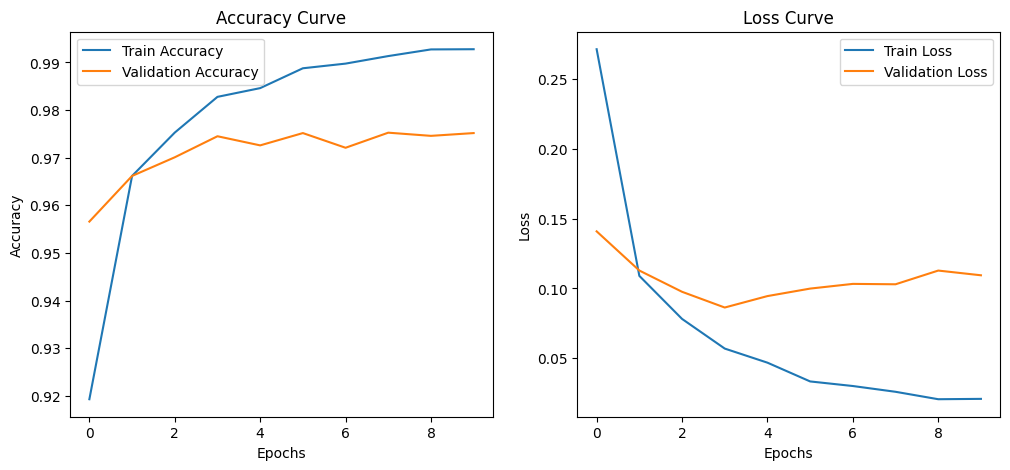

In [44]:
# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Create a figure with width and height
plt.figure(figsize=(12, 5))

# Accuracy Curve

plt.subplot(1, 2, 1)   # 1 row, 2 columns, first plot

# Plot training accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')

# Plot validation accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Add title and labels
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Show legend
plt.legend()

# Loss Curve

plt.subplot(1, 2, 2)   # 1 row, 2 columns, second plot

# Plot training loss
plt.plot(history.history['loss'], label='Train Loss')

# Plot validation loss
plt.plot(history.history['val_loss'], label='Validation Loss')

# Add title and labels
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Show legend
plt.legend()

# Display both plots
plt.show()


**Observations**

* Training and validation accuracy increase steadily with epochs.

* Training and validation loss decrease continuously.

* Small gap between training and validation curves indicates good generalization.

* The ANN learns handwritten digit patterns effectively.